# Plots

Load finished runs, inspect final-evaluation artifacts, and generate writeup figures/tables.

## Bootstrap

In [1]:
import json
import sys
from pathlib import Path

repo_root = Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print('repo_root =', repo_root)


repo_root = /content


## Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['lines.linewidth'] = 2.0


## Config

In [10]:
# Point this at the directory containing your run folders.
runs_root = Path('/content/drive/MyDrive/facialgen_checkpoints')

# Optionally pin a specific subset/order of runs here.
selected_runs = [
    # runs_root / 'coraml_facial_online_resistance_val_T0p50_L1_H1_D8',
    # runs_root / 'coraml_random_na_val_T0p50_L1_H1_D8',
]

# If left empty, the notebook will auto-discover all child directories under runs_root.
if not selected_runs:
    selected_runs = sorted([p for p in runs_root.glob('*') if p.is_dir()])

print('selected_runs =')
for p in selected_runs:
    print(' -', p)


selected_runs =
 - /content/drive/MyDrive/facialgen_checkpoints/coraml_facial_online_val_L1_H1_D8
 - /content/drive/MyDrive/facialgen_checkpoints/coraml_facial_online_val_T0p50_L1_H1_D8
 - /content/drive/MyDrive/facialgen_checkpoints/coraml_random_val_L1_H1_D8
 - /content/drive/MyDrive/facialgen_checkpoints/coraml_random_val_T0p50_L1_H1_D8


## Helpers

In [7]:
def load_run_artifacts(run_dir: Path) -> dict:
    out = {'run_dir': run_dir}

    train_args_path = run_dir / 'train_args.json'
    history_path = run_dir / 'history.json'
    meta_path = run_dir / 'final_eval_meta.json'
    lp_path = run_dir / 'final_eval_link_prediction.csv'
    stats_path = run_dir / 'final_eval_graph_stats.csv'
    diag_path = run_dir / 'final_eval_score_diagnostics.csv'

    out['train_args'] = json.loads(train_args_path.read_text()) if train_args_path.exists() else None
    out['history'] = pd.DataFrame(json.loads(history_path.read_text())) if history_path.exists() else pd.DataFrame()
    out['final_meta'] = json.loads(meta_path.read_text()) if meta_path.exists() else None
    out['final_lp'] = pd.read_csv(lp_path) if lp_path.exists() else pd.DataFrame()
    out['final_stats'] = pd.read_csv(stats_path) if stats_path.exists() else pd.DataFrame()
    out['final_diag'] = pd.read_csv(diag_path) if diag_path.exists() else pd.DataFrame()
    return out


def summarize_run(run: dict) -> dict:
    args = run.get('train_args') or {}
    lp = run.get('final_lp', pd.DataFrame())
    diag = run.get('final_diag', pd.DataFrame())
    meta = run.get('final_meta') or {}

    row = {
        'run_name': Path(run['run_dir']).name,
        'dataset': args.get('dataset_name'),
        'walk_type': args.get('walk_type'),
        'facial_walk_method': args.get('facial_walk_method'),
        'train_fraction': args.get('train_fraction'),
        'n_layer': args.get('n_layer'),
        'n_head': args.get('n_head'),
        'n_embd': args.get('n_embd'),
        'num_sign_configs': args.get('num_sign_configs'),
        'final_generated_walks': (meta.get('final_generated_walks_list') or [None])[0],
        'checkpoint_dir': meta.get('checkpoint_dir'),
        'gpu_transition_counts': meta.get('gpu_transition_counts'),
        'debug': meta.get('debug'),
    }

    if not lp.empty:
        first = lp.iloc[0].to_dict()
        for key, value in first.items():
            row[key] = value

    if not diag.empty:
        for _, rec in diag.iterrows():
            split = rec.get('split_name')
            if split is None:
                continue
            row[f'min_8S_over_sumS[{split}]'] = rec.get('min_8S_over_sumS')
            row[f'min_nonzero_gap[{split}]'] = rec.get('min_nonzero_gap')

    return row


def best_val_epoch(history: pd.DataFrame):
    if history.empty or 'val_score' not in history.columns:
        return None
    scores = pd.to_numeric(history['val_score'], errors='coerce')
    if scores.notna().sum() == 0:
        return None
    idx = scores.idxmax()
    epoch = history.loc[idx].get('epoch')
    return int(epoch) if pd.notna(epoch) else None


## Load Runs


In [11]:
runs = [load_run_artifacts(Path(p)) for p in selected_runs]
summary_df = pd.DataFrame([summarize_run(run) for run in runs])
summary_df = summary_df.sort_values(['dataset', 'train_fraction', 'walk_type', 'facial_walk_method'], na_position='last').reset_index(drop=True)
print(f'Loaded {len(runs)} runs')
display(summary_df)


Loaded 4 runs


,run_name,dataset,walk_type,facial_walk_method,train_fraction,n_layer,n_head,n_embd,num_sign_configs,final_generated_walks,checkpoint_dir,gpu_transition_counts,graph_id,val_roc_auc,val_ap,test_roc_auc,test_ap,edge_overlap[reference]
0,coraml_facial_online_val_T0p50_L1_H1_D8,coraml,facial_online,None,0.5,1,1,8,256,2000000,/content/drive/MyDrive/facialgen_checkpoints/c...,None,0.0,0.892010,0.900395,0.912469,0.921755,0.195214
1,coraml_random_val_T0p50_L1_H1_D8,coraml,random,None,0.5,1,1,8,256,2000000,/content/drive/MyDrive/facialgen_checkpoints/c...,None,0.0,0.860860,0.869573,0.844588,0.852004,0.156246
2,coraml_facial_online_val_L1_H1_D8,coraml,facial_online,None,NaN,1,1,8,256,500000,/content/drive/MyDrive/facialgen_checkpoints/c...,None,0.0,0.933106,0.934182,0.936863,0.937440,0.274903
3,coraml_random_val_L1_H1_D8,coraml,random,None,NaN,1,1,8,256,500000,/content/drive/MyDrive/facialgen_checkpoints/c...,None,0.0,0.925453,0.929337,0.943980,0.946603,0.175041


## Training Curves

/tmp/ipykernel_75588/3909936262.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  history_df = pd.concat(summary_with_history, ignore_index=True)


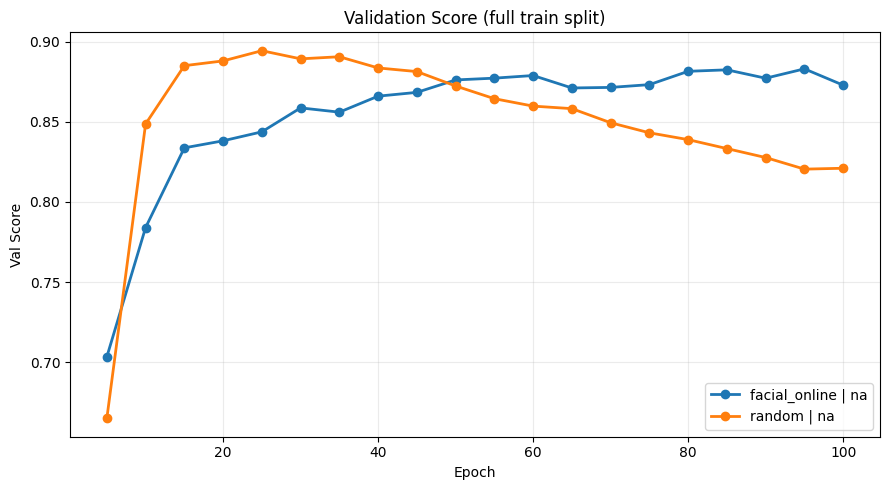

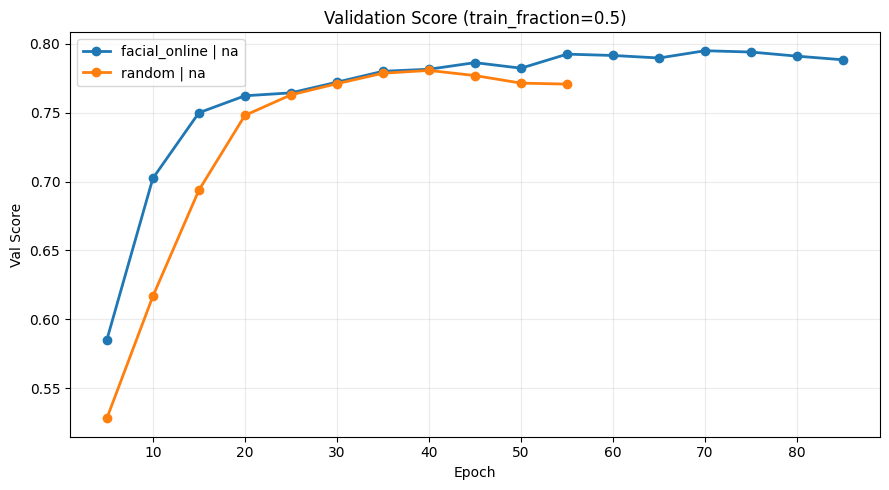

In [15]:
summary_with_history = []
for run in runs:
    history = run['history'].copy()
    if history.empty:
        continue
    args = run.get('train_args') or {}
    history['epoch'] = pd.to_numeric(history.get('epoch'), errors='coerce')
    history['val_score'] = pd.to_numeric(history.get('val_score'), errors='coerce')
    if 'edge_overlap' in history.columns:
        history['edge_overlap'] = pd.to_numeric(history.get('edge_overlap'), errors='coerce')
    history['run_name'] = Path(run['run_dir']).name
    history['walk_type'] = args.get('walk_type')
    history['facial_walk_method'] = args.get('facial_walk_method')
    history['train_fraction'] = args.get('train_fraction')
    summary_with_history.append(history)

if not summary_with_history:
    raise RuntimeError('No run histories found.')

history_df = pd.concat(summary_with_history, ignore_index=True)

val_df = history_df.dropna(subset=['epoch', 'val_score'])
if val_df.empty:
    raise RuntimeError('No validation scores found in the selected runs.')

for train_fraction, group in val_df.groupby('train_fraction', dropna=False, sort=False):
    train_label = 'full train split' if pd.isna(train_fraction) else f'train_fraction={train_fraction}'
    fig, ax = plt.subplots(figsize=(9, 5))
    for run_name, run_group in group.groupby('run_name', sort=False):
        run_group = run_group.sort_values('epoch')
        walk_type = run_group['walk_type'].iloc[0]
        method = run_group['facial_walk_method'].iloc[0]
        if pd.isna(method):
            method = 'na'
        label = f'{walk_type} | {method}'
        ax.plot(
            run_group['epoch'],
            run_group['val_score'],
            marker='o',
            linestyle='-',
            label=label,
        )

    ax.set_title(f'Validation Score ({train_label})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val Score')
    ax.legend()
    plt.tight_layout()
    plt.show()

edge_df = history_df.dropna(subset=['epoch', 'edge_overlap']) if 'edge_overlap' in history_df.columns else pd.DataFrame()
if not edge_df.empty:
    for train_fraction, group in edge_df.groupby('train_fraction', dropna=False, sort=False):
        train_label = 'full train split' if pd.isna(train_fraction) else f'train_fraction={train_fraction}'
        fig, ax = plt.subplots(figsize=(9, 5))
        for run_name, run_group in group.groupby('run_name', sort=False):
            run_group = run_group.sort_values('epoch')
            walk_type = run_group['walk_type'].iloc[0]
            method = run_group['facial_walk_method'].iloc[0]
            if pd.isna(method):
                method = 'na'
            label = f'{walk_type} | {method}'
            ax.plot(
                run_group['epoch'],
                100.0 * run_group['edge_overlap'],
                marker='o',
                linestyle='-',
                label=label,
            )

        ax.set_title(f'Edge Overlap (%) ({train_label})')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Edge Overlap (%)')
        ax.legend()
        plt.tight_layout()
        plt.show()


## Final Evaluation Tables

In [20]:
run_idx = 1
run = runs[run_idx]
print('run_dir =', run['run_dir'])
print('final_meta =')
display(pd.DataFrame([run['final_meta']]) if run['final_meta'] else pd.DataFrame())

print('final link prediction =')
display(run['final_lp'])

print('final graph statistics =')
display(run['final_stats'])

print('final score diagnostics =')
display(run['final_diag'])


run_dir = /content/drive/MyDrive/facialgen_checkpoints/coraml_facial_online_val_T0p50_L1_H1_D8
final_meta =


,dataset_name,walk_type,score_symmetrization,edge_overlap_target,final_generated_walks,final_max_length,generation_batch_size,num_generated_graphs,reconstruction_seed,checkpoint_dir
0,coraml,facial_online,sum,reference,2000000,17,2048,1,777,/content/drive/MyDrive/facialgen_checkpoints/c...


final link prediction =


,graph_id,val_roc_auc,val_ap,test_roc_auc,test_ap,edge_overlap[reference]
0,0,0.89201,0.900395,0.912469,0.921755,0.195214


final graph statistics =


,metric,reference,generated_mean,generated_std
0,max_degree,246.000000,238.000000,0.0
1,assortativity,-0.076592,-0.055451,0.0
2,triangle_count,5247.000000,1238.000000,0.0
3,power_law_exp,1.500883,1.491288,0.0
4,clustering_coeff,0.114298,0.029402,0.0
5,characteristic_path_len,5.271418,4.152886,0.0
6,inter_community_density,0.000526,0.001422,0.0
7,intra_community_density,0.009280,0.004934,0.0


final score diagnostics =


,graph_id,split,num_edges,min_8S_over_sumS,min_nonzero_gap
0,0,train,3990,0.0,5.000000e-07
1,0,validation,1197,0.0,5.000000e-07
2,0,test,400,0.0,5.000000e-07


## Comparison Plot

In [ ]:
plot_df = summary_df.copy()

# Example: compare test ROC-AUC across runs.
metric_col = 'test_roc_auc'
label_cols = ['walk_type', 'facial_walk_method', 'train_fraction', 'n_embd']
plot_df['label'] = plot_df[label_cols].astype(str).agg(' | '.join, axis=1)
plot_df = plot_df.dropna(subset=[metric_col])
plot_df = plot_df.sort_values(metric_col, ascending=False)

fig, ax = plt.subplots(figsize=(12, max(4, 0.45 * len(plot_df))))
ax.barh(plot_df['label'], plot_df[metric_col])
ax.invert_yaxis()
ax.set_title(metric_col)
ax.set_xlabel(metric_col)
plt.tight_layout()
plt.show()


## Paper Table

In [ ]:
paper_cols = [
    'run_name',
    'walk_type',
    'facial_walk_method',
    'train_fraction',
    'num_sign_configs',
    'n_layer',
    'n_head',
    'n_embd',
    'test_roc_auc',
    'test_ap',
]

paper_table = summary_df[[c for c in paper_cols if c in summary_df.columns]].copy()
display(paper_table)
